In [40]:
# 케라스
import tensorflow as tf
fasion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(x_train_full,y_train_full),(x_test,y_test) =   fasion_mnist
x_train_full.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [41]:
x_train, y_train = x_train_full[:-5000],y_train_full[:-5000]
x_valid, y_valid = x_train_full[-5000:],y_train_full[-5000:]
x_train.shape, x_valid.shape

((55000, 28, 28), (5000, 28, 28))

In [42]:
x_train, x_valid, x_test = x_train / 255. , x_valid / 255. , x_test / 255

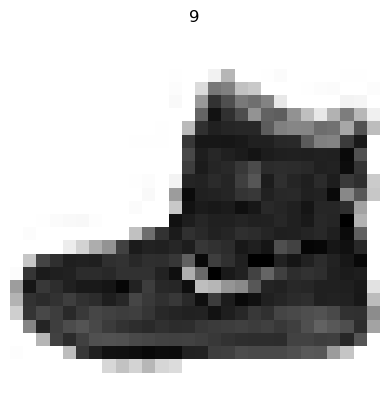

In [60]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='binary')
plt.axis('off')
plt.title(y_train[0])
plt.show()

In [44]:
# 다중 분류 (multi class, 단일 정답)
# 마지막 출력층 softmax = 모든 출력의 합이 1, 확률 분포형태
# 각 클래스별로 확률값

import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add( tf.keras.layers.Input(shape=(28,28)) )
model.add( tf.keras.layers.Flatten() ) 
model.add( tf.keras.layers.Dense(300, activation='relu') )
model.add( tf.keras.layers.Dense(100, activation='relu') )
model.add( tf.keras.layers.Dense(10, activation='softmax') ) # 마지막 확률분포

In [45]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.layers

[<Flatten name=flatten_3, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>,
 <Dense name=dense_11, built=True>]

In [48]:
# 컴파일 
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'sgd',
    metrics = ['accuracy']
)

In [49]:
history = model.fit(x_train, y_train, epochs=30,
                    validation_data=(x_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7585 - loss: 0.7304 - val_accuracy: 0.8310 - val_loss: 0.5096
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8309 - loss: 0.4901 - val_accuracy: 0.8418 - val_loss: 0.4529
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8467 - loss: 0.4422 - val_accuracy: 0.8498 - val_loss: 0.4255
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8552 - loss: 0.4132 - val_accuracy: 0.8552 - val_loss: 0.4091
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8623 - loss: 0.3926 - val_accuracy: 0.8550 - val_loss: 0.3975
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8680 - loss: 0.3767 - val_accuracy: 0.8592 - val_loss: 0.3890
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8719 - loss: 0.3632 - val_accuracy: 0.8594 - val_loss: 0.3834
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8752 - loss: 0.3515 - 

In [63]:
predict = model.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [51]:
import numpy as np
np.argmax(predict[0])

np.int64(9)

In [52]:
np.argmax(predict, axis=1)

array([9, 2, 1, 1, 6])

In [53]:
y_test[:5]

array([9, 2, 1, 1, 6], dtype=uint8)

In [65]:
predict = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step


In [66]:
sum(np.argmax(predict, axis=1)== y_test) / len(y_test)

np.float64(0.8695)

In [68]:
from sklearn.metrics import classification_report
print( classification_report(y_test, np.argmax(predict, axis=1)) )

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.78      0.81      0.79      1000
           3       0.78      0.94      0.86      1000
           4       0.80      0.80      0.80      1000
           5       0.87      0.98      0.92      1000
           6       0.74      0.65      0.70      1000
           7       0.94      0.90      0.92      1000
           8       0.96      0.96      0.96      1000
           9       0.98      0.91      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [71]:
history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

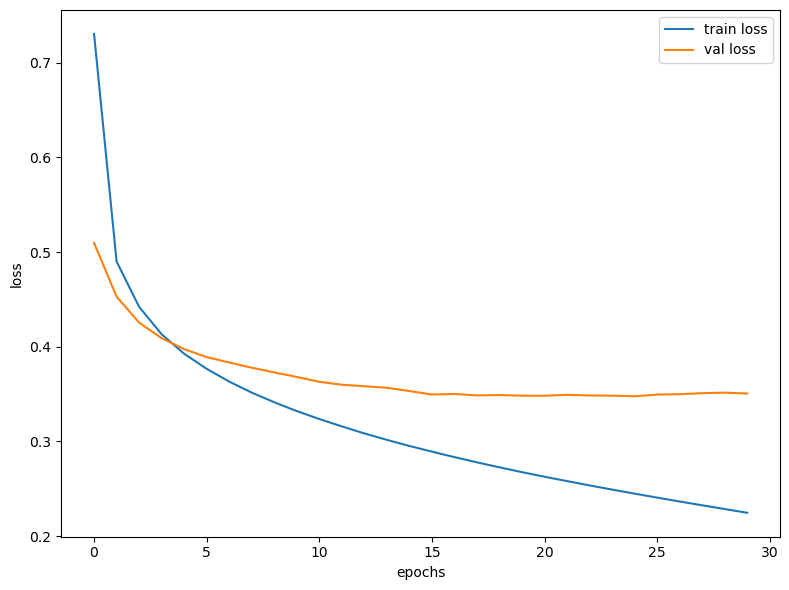

In [78]:
# x 축은 range(30)
# y 축은 loss, val_loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(range(30), history.history['loss'], label = 'train loss')
plt.plot(range(30), history.history['val_loss'], label = 'val loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.tight_layout()
plt.show()